# Mini Project #1: Data Cleaning with Cobblestone Gifts
**EECE 5644: Introduction to Machine Learning and Pattern Recognition; Summer 2 2026**

This notebook profiles a raw e-commerce export, documents the cleaning decisions,
builds a completed-sales dataset, and uses it to answer seven business questions.

Notes on how the notebook is organised:

* The raw DataFrame (`raw`) is loaded once and is never modified, so it stays as
  the source of truth. Every cleaning step produces a new object, and `sales` is
  the final clean dataset.
* Each of the 21 required techniques has its own header labelled by number, for
  example `### 3.13 Dropping duplicates`, so the steps are easy to find.
* The work follows Phases A to E from the brief.

Dataset: UK Online Retail (UCI / Kaggle `carrie1/ecommerce-data`), ~541,909
transactions from December 2010 - December 2011. The data is not UTF-8, so
the line `encoding='ISO-8859-1'` has to be used or the `£` symbol will raise a decoding
error.

In [3]:
# Notebook-wide imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Set the figure parameters for numpy and matplotlib
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True

# Make a directory to store the charts
os.makedirs('charts', exist_ok=True)

# Display the version for pandas & numpy to ensure they are installed
print('pandas: version ', pd.__version__, '| numpy: version ', np.__version__)

pandas: version  3.0.3 | numpy: version  2.5.0


---
# PHASE A. Load and profile

### 3.2 Getting information
Load `data.csv` with the correct encoding, then report `shape`, `head()`,
`info()`, and `describe()`. The last cell lists which columns have missing values
and how many.

In [ ]:
# Read once with the Latin-1 encoding. This object is kept unchanged throughout.
raw = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Display the shape of the data in the form (rows, columns)
print('shape:', raw.shape)

# Display the head of the raw data
raw.head()

shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
# describe() across numeric and text columns for a quick quality read
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Which columns have missing values, and how many
missing = raw.isnull().sum()

# Percentage of columns missing
missing_pct = (missing / len(raw) * 100).round(2)

# Display the information about missing columns
pd.DataFrame({'missing': missing, 'missing_%': missing_pct}).query('missing > 0').sort_values('missing', ascending=False)

,missing,missing_%
CustomerID,135080,24.93
Description,1454,0.27


The export has 541,909 rows and 8 columns. Only two columns contain missing
values: `CustomerID` (135,080 rows, roughly 25%) and `Description` (1,454 rows). The missing `CustomerID` rows are the main decision point in this
project and are handled in 3.10.

### 3.9 Unique values
Use `value_counts()` and `nunique()` on `Country`, `StockCode`, and `Description`
to surface non-product codes, and `value_counts(dropna=False)` to show the missing
entries.

In [8]:
print('Distinct countries   :', raw['Country'].nunique())
print('Distinct stock codes :', raw['StockCode'].nunique())
print('Distinct descriptions:', raw['Description'].nunique())

raw['Country'].value_counts().head(10)

Distinct countries   : 38
Distinct stock codes : 4070
Distinct descriptions: 4223


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [9]:
# Surface non-product stock codes. Genuine product codes are 5 digits, sometimes
# with a trailing letter (for example 85123A). Anything else is a service or
# adjustment line such as POST, DOT, M, BANK CHARGES, AMAZONFEE, C2, or a gift card.
non_product_mask = ~raw['StockCode'].astype(str).str.match(r'^\d{5}')
print('Rows with non-product stock codes:', non_product_mask.sum())
raw.loc[non_product_mask, 'StockCode'].value_counts().head(20)

Rows with non-product stock codes: 2995


StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
gift_0001_50       4
PADS               4
gift_0001_40       3
B                  3
DCGS0076           2
Name: count, dtype: int64

In [10]:
# value_counts(dropna=False) shows the missing Description entries directly
raw['Description'].value_counts(dropna=False).head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
NaN                                   1454
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
Name: count, dtype: int64

### 3.8 Min, max, sum, mean, count
Summarise `Quantity` and `UnitPrice`, then quantify the negative quantities
(returns and cancellations) and the zero or negative prices that cannot be valid
sales.

In [11]:
raw[['Quantity', 'UnitPrice']].agg(['min', 'max', 'sum', 'mean', 'count'])

,Quantity,UnitPrice
min,-8.099500e+04,-1.106206e+04
max,8.099500e+04,3.897000e+04
sum,5.176450e+06,2.498804e+06
mean,9.552250e+00,4.611114e+00
count,5.419090e+05,5.419090e+05


In [12]:
print('Negative quantity rows (returns/cancellations):', (raw['Quantity'] < 0).sum())
print('Zero quantity rows                            :', (raw['Quantity'] == 0).sum())
print('Zero-price rows                               :', (raw['UnitPrice'] == 0).sum())
print('Negative-price rows                           :', (raw['UnitPrice'] < 0).sum())

Negative quantity rows (returns/cancellations): 10624
Zero quantity rows                            : 0
Zero-price rows                               : 2515
Negative-price rows                           : 2


Both `Quantity` and `UnitPrice` contain impossible extremes (quantities of about
plus or minus 80,995, prices up to roughly 38,970 and as low as about -11,062).
These sit on cancellation, adjustment, and bad-debt lines and are removed in 3.12.

### 3.1 Creating a DataFrame
Build a small country to region lookup table from a Python dictionary. It is
merged onto the clean data in 3.21.

In [ ]:
region_map = {
    'United Kingdom': 'UK&IE', 'Ireland': 'UK&IE', 'EIRE': 'UK&IE',
    'France': 'Western Europe', 'Germany': 'Western Europe',
    'Netherlands': 'Western Europe', 'Belgium': 'Western Europe',
    'Switzerland': 'Western Europe', 'Austria': 'Western Europe',
    'Spain': 'Southern Europe', 'Portugal': 'Southern Europe',
    'Italy': 'Southern Europe', 'Greece': 'Southern Europe', 'Malta': 'Southern Europe',
    'Cyprus': 'Southern Europe',
    'Sweden': 'Nordics', 'Norway': 'Nordics', 'Finland': 'Nordics',
    'Denmark': 'Nordics', 'Iceland': 'Nordics',
    'Poland': 'Eastern Europe', 'Czech Republic': 'Eastern Europe',
    'Lithuania': 'Eastern Europe',
    'USA': 'North America', 'Canada': 'North America',
    'Australia': 'APAC', 'Japan': 'APAC', 'Singapore': 'APAC',
    'Israel': 'Middle East', 'Lebanon': 'Middle East', 'Bahrain': 'Middle East',
    'Saudi Arabia': 'Middle East', 'United Arab Emirates': 'Middle East',
    'Brazil': 'Latin America',
    'South Africa': 'Africa', 'RSA': 'Africa',
    'Channel Islands': 'UK&IE', 'European Community': 'Western Europe',
}
region_lookup = pd.DataFrame(
    {'country': list(region_map.keys()), 'region': list(region_map.values())}
)
print('Lookup rows:', len(region_lookup))
region_lookup.head()

Lookup rows: 38


,country,region
0,United Kingdom,UK&IE
1,Ireland,UK&IE
2,EIRE,UK&IE
3,France,Western Europe
4,Germany,Western Europe


---
# PHASE B. Select and filter

### 3.3 Slicing
Inspect row ranges with `iloc`, create a unique line-item index, and retrieve rows
by label with `loc`.

In [14]:
# Positional slicing with iloc: first 5 rows, first 4 columns
raw.iloc[0:5, 0:4]

,InvoiceNo,StockCode,Description,Quantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,71053,WHITE METAL LANTERN,6
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6


In [15]:
# Build a unique line-item index (one id per transaction line) on a new object so
# raw is left untouched.
indexed = raw.copy()
indexed.insert(0, 'line_id', ['L{:06d}'.format(i) for i in range(len(indexed))])
indexed = indexed.set_index('line_id')

# Label-based retrieval with loc
indexed.loc[['L000000', 'L000010', 'L541908']]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
line_id,,,,,,,,
L000000,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
L000010,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,12/1/2010 8:34,2.10,13047.0,United Kingdom
L541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


### 3.4 Conditional selection
Isolate cancellations (`InvoiceNo` starts with `C`), rows where `Quantity <= 0`,
and rows where `UnitPrice <= 0`, and count each group.

In [58]:
# Helper that holds the first character of the invoice number. It is used again in
# 3.18 and dropped in 3.11.
invoice_initial = raw['InvoiceNo'].astype(str).str[0]

is_cancel    = invoice_initial.eq('C')
nonpos_qty   = raw['Quantity'] <= 0
nonpos_price = raw['UnitPrice'] <= 0

# Go through and match each cancellation to the original sale it reversed.
order_dt = pd.to_datetime(raw['InvoiceDate'], format='%m/%d/%Y %H:%M')
key = ['CustomerID', 'StockCode', 'UnitPrice']

# Candidate originals: real purchases only (not cancellations, positive quantity),
# grouped by the match key and sorted so the earliest is first.
raw_by_key = {k: g.assign(dt=order_dt.loc[g.index]).sort_values('dt')
              for k, g in raw.loc[~is_cancel & (raw['Quantity'] > 0)].groupby(key)}

cancelled = []          # indices in `raw` of the original sales that were cancelled
claimed   = set()
for i, order in raw.loc[is_cancel].iterrows():
    g = raw_by_key.get((order['CustomerID'], order['StockCode'], order['UnitPrice']))
    if g is None:                       # no candidate (often a NaN CustomerID)
        continue
    need = -order['Quantity']           # units the cancellation reverses
    cand = g[(g['dt'] <= order_dt.loc[i]) &         # original predates the cancel
             (g['Quantity'] >= need) &              # covers the cancelled amount
             (~g.index.isin(claimed))]              # not already used
    if len(cand):
        cancelled.append(cand.index[0])
        claimed.add(cand.index[0])
cancelled = pd.Index(cancelled)

print('Cancellation lines (InvoiceNo starts with C):', is_cancel.sum())
print('Quantity <= 0 lines                         :', nonpos_qty.sum())
print('UnitPrice <= 0 lines                        :', nonpos_price.sum())
print('Cancelled originals matched & flagged       :', len(cancelled))

# Example of conditional selection: a few cancellation rows
raw.loc[is_cancel].head()

Cancellation lines (InvoiceNo starts with C): 9288
Quantity <= 0 lines                         : 10624
UnitPrice <= 0 lines                        : 2517
Cancelled originals matched & flagged       : 7006


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


### 3.5 Sorting values
Sort by `Quantity` and by line revenue to find the largest bulk orders and the
largest returns.

In [17]:
# Largest single returns (most negative quantities)
raw.sort_values('Quantity').head(5)[['InvoiceNo','StockCode','Description','Quantity','UnitPrice']]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04
225529,556690,23005,printing smudges/thrown away,-9600,0.00
225530,556691,23005,printing smudges/thrown away,-9600,0.00
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03


In [18]:
# Largest bulk orders by line revenue (Quantity * UnitPrice)
line_rev = raw.assign(line_revenue=raw['Quantity'] * raw['UnitPrice'])
line_rev.sort_values('line_revenue', ascending=False) \
        .head(5)[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','line_revenue']]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06


---
# PHASE C. Clean and fix

The clean dataset is built here as a new object, one step at a time, leaving `raw`
untouched. The number of rows removed at each step is recorded for the
data-quality memo in Question 7.

In [19]:
# Start the cleaning pipeline from a copy of raw.
df = raw.copy()
removal_log = {'raw_rows': len(df)}
print('Starting rows:', len(df))

Starting rows: 541909


### 3.6 Replacing values
Standardise the country labels: `EIRE` becomes `Ireland`, `RSA` becomes
`South Africa`, and `Unspecified` becomes missing (NaN).

In [20]:
df['Country'] = df['Country'].replace({
    'EIRE': 'Ireland',
    'RSA': 'South Africa',
    'Unspecified': np.nan,
})
print('Country now distinct:', df['Country'].nunique())
print('Country NaN after mapping Unspecified:', df['Country'].isna().sum())

Country now distinct: 37
Country NaN after mapping Unspecified: 446


### 3.7 Renaming columns
Rename all columns to snake_case.

In [21]:
df = df.rename(columns={
    'InvoiceNo': 'invoice_no', 'StockCode': 'stock_code', 'Description': 'description',
    'Quantity': 'quantity', 'InvoiceDate': 'invoice_date', 'UnitPrice': 'unit_price',
    'CustomerID': 'customer_id', 'Country': 'country',
})
# Keep the cancellation-initial helper from 3.4 so it can be dropped in 3.11.
df['invoice_initial'] = df['invoice_no'].astype(str).str[0]
list(df.columns)

['invoice_no',
 'stock_code',
 'description',
 'quantity',
 'invoice_date',
 'unit_price',
 'customer_id',
 'country',
 'invoice_initial']

### 3.10 Handling missing values
Quantify the missingness, then decide and justify a policy for the missing
`customer_id` and blank `description`. The cells below use `isnull()`, `fillna()`,
and `dropna()`.

In [22]:
# Quantify
print(df[['customer_id', 'description', 'country']].isnull().sum())

customer_id    135080
description      1454
country           446
dtype: int64


**Policy and justification**

* Blank `description` (about 1,454 rows): these lines almost always also have a
  `unit_price` of 0 and a non-product code, so they are adjustment or bad-data
  lines rather than real sales. They are dropped with `dropna` when the sales
  table is built.
* Missing `customer_id` (about 25%): these are still genuine completed sales (real
  product, positive quantity and price). Dropping a quarter of the data would
  understate total revenue, best-sellers, and market size. The decision is to keep
  these rows and fill the missing id with the value `GUEST` so it is explicit.
  Customer-level questions (Q3 distinct customers, Q4 concentration) then exclude
  `GUEST`. This keeps revenue totals correct without inventing customer identities.

In [23]:
# Apply the policy: fill missing ids with the GUEST sentinel (new column values).
df['customer_id'] = df['customer_id'].fillna('GUEST')
# For known ids, show them as plain integer-like strings (no trailing .0)
def fmt_cid(x):
    return 'GUEST' if x == 'GUEST' else str(int(float(x)))
df['customer_id'] = df['customer_id'].apply(fmt_cid)
df['customer_id'].value_counts(dropna=False).head(5)

customer_id
GUEST    135080
17841      7983
14911      5903
14096      5128
12748      4642
Name: count, dtype: int64

### 3.11 Deleting a column
Drop a column that is not used in the final analysis, and explain why.

In [24]:
# invoice_initial was only a helper for flagging cancellations (3.4 and below). It
# can be recreated from invoice_no at any time and is not needed in the final
# analysis, so it is dropped to keep the schema clean.
df = df.drop(columns=['invoice_initial'])
print('Columns after drop:', list(df.columns))

Columns after drop: ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


### 3.12 Deleting a row
Remove cancellations, non-product lines, and impossible prices and quantities to
build a clean completed-sales DataFrame. Each filter is counted.

In [25]:
before = len(df)

# 1) Cancellations (InvoiceNo starts with 'C')
mask_cancel = df['invoice_no'].astype(str).str.startswith('C')
removal_log['cancellations'] = int(mask_cancel.sum())
df = df.loc[~mask_cancel]

# 2) Non-product lines (stock code is not a 5-digit product code)
mask_nonprod = ~df['stock_code'].astype(str).str.match(r'^\d{5}')
removal_log['non_product_lines'] = int(mask_nonprod.sum())
df = df.loc[~mask_nonprod]

# 3) Non-positive quantities (returns or adjustments not already removed)
mask_qty = df['quantity'] <= 0
removal_log['nonpositive_quantity'] = int(mask_qty.sum())
df = df.loc[~mask_qty]

# 4) Non-positive prices
mask_price = df['unit_price'] <= 0
removal_log['nonpositive_price'] = int(mask_price.sum())
df = df.loc[~mask_price]

# 5) Blank descriptions (per the 3.10 policy)
mask_desc = df['description'].isnull()
removal_log['blank_description'] = int(mask_desc.sum())
df = df.dropna(subset=['description'])

print('Rows removed by the Phase C row-filters:', before - len(df))
print('Rows remaining                        :', len(df))
removal_log

Rows removed by the Phase C row-filters: 14184
Rows remaining                        : 527725


{'raw_rows': 541909,
 'cancellations': 9288,
 'non_product_lines': 2411,
 'nonpositive_quantity': 1324,
 'nonpositive_price': 1161,
 'blank_description': 0}

### 3.13 Dropping duplicates
Detect exact duplicates with `duplicated().sum()` and remove them with
`drop_duplicates()`. Report how many rows were dropped.

In [26]:
dups = int(df.duplicated().sum())
print('Exact duplicate rows detected:', dups)
df = df.drop_duplicates()
removal_log['exact_duplicates'] = dups
print('Rows after de-duplication:', len(df))

Exact duplicate rows detected: 5221
Rows after de-duplication: 522504


---
# PHASE D. Engineer and summarise

`df` is now the clean completed-sales table. The cells below engineer features and
aggregate the data.

### 3.18 Applying a function
Add a `revenue = quantity * unit_price` column, use `apply` to clean `description`
(strip and title-case), and use `apply` to flag cancelled invoices.

In [27]:
# Revenue is computed with a vectorised multiplication.
df['revenue'] = df['quantity'] * df['unit_price']

# apply to clean the description text (strip whitespace, then title-case)
df['description'] = df['description'].apply(lambda s: str(s).strip().title())

# apply to flag cancelled invoices. These are all False now because cancellations
# were removed in 3.12, which also confirms the clean table holds no cancellations.
df['is_cancelled'] = df['invoice_no'].apply(lambda x: str(x).startswith('C'))
print('Any cancelled invoices left in the clean data?', df['is_cancelled'].any())
df[['description', 'quantity', 'unit_price', 'revenue']].head()

Any cancelled invoices left in the clean data? False


,description,quantity,unit_price,revenue
0,White Hanging Heart T-Light Holder,6,2.55,15.30
1,White Metal Lantern,6,3.39,20.34
2,Cream Cupid Hearts Coat Hanger,8,2.75,22.00
3,Knitted Union Flag Hot Water Bottle,6,3.39,20.34
4,Red Woolly Hottie White Heart.,6,3.39,20.34


### 3.17 Looping over a column
Show a `for`-loop and a list comprehension over a column, then explain why the
vectorised `apply` approach is preferred.

In [28]:
import time

sample = df['unit_price'].head(20000)

# Explicit Python for-loop
t0 = time.perf_counter()
out_loop = []
for p in sample:
    out_loop.append(round(p * 1.20, 2))   # add 20% VAT
t_loop = time.perf_counter() - t0

# List comprehension (same result)
out_lc = [round(p * 1.20, 2) for p in sample]

# Vectorised version with pandas/numpy
t0 = time.perf_counter()
out_vec = (sample * 1.20).round(2)
t_vec = time.perf_counter() - t0

print(f'for-loop  : {t_loop*1000:7.2f} ms')
print(f'vectorised: {t_vec*1000:7.2f} ms')
print(f'speed-up  : about {t_loop / max(t_vec, 1e-9):.0f}x')

for-loop  :    9.27 ms
vectorised:    0.45 ms
speed-up  : about 21x


The explicit `for`-loop runs the Python interpreter once per element and appends to
a list, while the vectorised version sends the whole column to compiled C and
NumPy code in a single call. On 20,000 rows it is already many times faster, and
the gap grows with the size of the data, so the notebook uses vectorised
operations (and `apply` where a custom function is needed) throughout.

### 3.14 Grouping by values
Use `groupby` to compute revenue by `country` and the number of orders per
customer.

In [29]:
rev_by_country = df.groupby('country')['revenue'].sum().sort_values(ascending=False)
rev_by_country.head(10)

country
United Kingdom    8724045.22
Netherlands        283889.34
Ireland            270850.86
Germany            205381.15
France             184493.00
Australia          138103.81
Spain               55706.56
Switzerland         53065.60
Japan               37416.37
Belgium             36927.34
Name: revenue, dtype: float64

In [30]:
# Orders per customer is the count of distinct invoices per customer (GUEST excluded)
orders_per_customer = (
    df.loc[df['customer_id'] != 'GUEST']
      .groupby('customer_id')['invoice_no'].nunique()
      .sort_values(ascending=False)
)
orders_per_customer.head(10)

customer_id
12748    206
14911    198
17841    124
13089     97
15311     91
14606     90
12971     86
14646     72
13408     62
16029     62
Name: invoice_no, dtype: int64

### 3.16 Aggregating
Use `agg` to produce several statistics at once (total revenue, mean line value,
line count, order count) per country and per customer.

In [31]:
country_stats = df.groupby('country').agg(
    total_revenue=('revenue', 'sum'),
    mean_line_value=('revenue', 'mean'),
    n_lines=('revenue', 'count'),
    n_orders=('invoice_no', 'nunique'),
).sort_values('total_revenue', ascending=False)
country_stats.head(10)

,total_revenue,mean_line_value,n_lines,n_orders
country,,,,
United Kingdom,8724045.22,18.219200,478838,17901
Netherlands,283889.34,122.260698,2322,93
Ireland,270850.86,34.867515,7768,282
Germany,205381.15,23.762715,8643,443
France,184493.00,22.819171,8085,382
Australia,138103.81,117.037127,1180,56
Spain,55706.56,23.047811,2417,88
Switzerland,53065.60,27.537935,1927,50
Japan,37416.37,116.561900,321,19


In [32]:
customer_stats = (
    df.loc[df['customer_id'] != 'GUEST']
      .groupby('customer_id').agg(
          total_spend=('revenue', 'sum'),
          mean_line_value=('revenue', 'mean'),
          n_lines=('revenue', 'count'),
          n_orders=('invoice_no', 'nunique'),
      ).sort_values('total_spend', ascending=False)
)
customer_stats.head(10)

,total_spend,mean_line_value,n_lines,n_orders
customer_id,,,,
14646,279138.02,135.503893,2060,72
18102,259657.30,602.453132,431,60
17450,194390.79,578.544018,336,46
16446,168472.50,56157.500000,3,2
14911,136161.83,24.384282,5584,198
12415,124564.53,174.704811,713,20
14156,116560.08,84.341592,1382,54
17511,91062.38,94.561142,963,31
12346,77183.60,77183.600000,1,1


### 3.19 Applying to groups
Use `groupby(...).apply(...)` for a per-customer summary that returns total spend
and the number of active months.

In [33]:
# Parse the dates first (also needed in 3.15).
df['invoice_dt'] = pd.to_datetime(df['invoice_date'], format='%m/%d/%Y %H:%M')

def customer_summary(g):
    return pd.Series({
        'total_spend': g['revenue'].sum(),
        'n_orders': g['invoice_no'].nunique(),
        'active_months': g['invoice_dt'].dt.to_period('M').nunique(),
    })

per_customer = (
    df.loc[df['customer_id'] != 'GUEST']
      .groupby('customer_id')
      .apply(customer_summary)
      .sort_values('total_spend', ascending=False)
)
per_customer.head(10)

,total_spend,n_orders,active_months
customer_id,,,
14646,279138.02,72.0,13.0
18102,259657.30,60.0,12.0
17450,194390.79,46.0,12.0
16446,168472.50,2.0,2.0
14911,136161.83,198.0,13.0
12415,124564.53,20.0,10.0
14156,116560.08,54.0,12.0
17511,91062.38,31.0,13.0
12346,77183.60,1.0,1.0


### 3.15 Grouping by time
Parse `invoice_date` to datetime, set it as the index, and `resample` monthly and
weekly to chart the revenue trend.

In [34]:
ts = df.set_index('invoice_dt').sort_index()

monthly_revenue = ts['revenue'].resample('ME').sum()
weekly_revenue  = ts['revenue'].resample('W').sum()

print('Monthly revenue (GBP):')
print(monthly_revenue.round(0).astype('int64'))

Monthly revenue (GBP):
invoice_dt
2010-12-31     775572
2011-01-31     670362
2011-02-28     507783
2011-03-31     689708
2011-04-30     515355
2011-05-31     739914
2011-06-30     737559
2011-07-31     688145
2011-08-31     724197
2011-09-30    1028314
2011-10-31    1103311
2011-11-30    1452113
2011-12-31     614488
Freq: ME, Name: revenue, dtype: int64


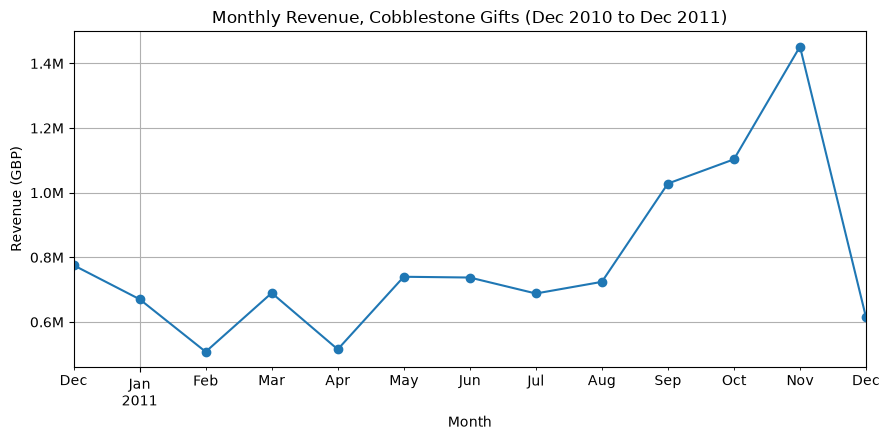

In [35]:
# Chart 1: monthly revenue trend
fig, ax = plt.subplots()
monthly_revenue.plot(ax=ax, marker='o', color='#1f77b4')
ax.set_title('Monthly Revenue, Cobblestone Gifts (Dec 2010 to Dec 2011)')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (GBP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))
fig.tight_layout()
fig.savefig('charts/monthly_revenue.png', dpi=120)
plt.show()

---
# PHASE E. Combine

### 3.20 Concatenating
Split the clean data into two periods (first and second half of the year) and
`concat` them back together, which simulates merging two monthly extracts.

In [36]:
cutoff = pd.Timestamp('2011-07-01')
first_half  = df.loc[df['invoice_dt'] <  cutoff]
second_half = df.loc[df['invoice_dt'] >= cutoff]
print('First half rows :', len(first_half))
print('Second half rows:', len(second_half))

recombined = pd.concat([first_half, second_half], axis=0)
print('Recombined rows :', len(recombined), '| matches original:', len(recombined) == len(df))

First half rows : 236732
Second half rows: 285772
Recombined rows : 522504 | matches original: True


### 3.21 Merging
Use `merge` to add a `region` column from the lookup. Compare an inner join with a
left join and note which countries fail to match.

In [37]:
left_join  = df.merge(region_lookup, on='country', how='left')
inner_join = df.merge(region_lookup, on='country', how='inner')

print('Rows, left join :', len(left_join))
print('Rows, inner join:', len(inner_join))
print('Rows lost by the inner join (unmatched countries):', len(left_join) - len(inner_join))

unmatched = sorted(left_join.loc[left_join['region'].isna(), 'country'].dropna().unique())
print('\nCountries with no region match:', unmatched if unmatched else 'none')

# Use the left join as the enriched dataset so every sales row is kept.
sales = left_join.copy()
sales['region'] = sales['region'].fillna('Other')
sales['region'].value_counts()

Rows, left join : 522504
Rows, inner join: 521787
Rows lost by the inner join (unmatched countries): 717

Countries with no region match: ['Hong Kong']


region
UK&IE              487349
Western Europe      23353
Southern Europe      5465
Nordics              2671
APAC                 1716
Other                 717
Middle East           431
Eastern Europe        384
North America         329
Africa                 57
Latin America          32
Name: count, dtype: int64

The left join keeps every sales row even when a country has no region entry,
filling the gap with `Other`. The inner join drops those rows instead. The left
join is preferred for revenue totals so that no sales are lost. `sales` is now the
final enriched completed-sales dataset.

---
## Export the cleaned dataset
Export the final columns to `clean_online_retail.csv`.

In [38]:
final_cols = ['invoice_no', 'stock_code', 'description', 'quantity', 'unit_price',
              'revenue', 'invoice_dt', 'customer_id', 'country', 'region']
clean_export = sales[final_cols].rename(columns={'invoice_dt': 'invoice_date'})
clean_export.to_csv('clean_online_retail.csv', index=False, encoding='utf-8')
print('Exported clean_online_retail.csv, shape:', clean_export.shape)
clean_export.head()

Exported clean_online_retail.csv, shape: (522504, 10)


,invoice_no,stock_code,description,quantity,unit_price,revenue,invoice_date,customer_id,country,region
0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,15.30,2010-12-01 08:26:00,17850,United Kingdom,UK&IE
1,536365,71053,White Metal Lantern,6,3.39,20.34,2010-12-01 08:26:00,17850,United Kingdom,UK&IE
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,22.00,2010-12-01 08:26:00,17850,United Kingdom,UK&IE
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,20.34,2010-12-01 08:26:00,17850,United Kingdom,UK&IE
4,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,20.34,2010-12-01 08:26:00,17850,United Kingdom,UK&IE


---
# Part 2. Business questions

All answers use the clean `sales` dataset.

### Q1. Seasonality: total revenue and monthly breakdown

In [39]:
total_revenue = sales['revenue'].sum()
print(f'Total revenue for the year: GBP {total_revenue:,.0f}')

monthly = sales.set_index('invoice_dt')['revenue'].resample('ME').sum()
peak_month = monthly.idxmax()
avg_other  = monthly.drop(peak_month).mean()
print(f'Peak month: {peak_month:%B %Y} (GBP {monthly.max():,.0f})')
print(f'Average of the other months: GBP {avg_other:,.0f}')
print(f'Peak lift over a typical month: +{(monthly.max()/avg_other - 1)*100:.0f}%')

Total revenue for the year: GBP 10,246,821
Peak month: November 2011 (GBP 1,452,113)
Average of the other months: GBP 732,892
Peak lift over a typical month: +98%


Total cleaned revenue is about 10.2 million pounds. Sales rise through the autumn
and peak in November 2011 at about 1.45 million pounds, which is roughly double a
typical month (about +98%) and matches the pre-Christmas wholesale restocking
period. December 2011 looks low only because the export ends on 9 December. The
business is strongly seasonal, so stock and cash planning should expect a large
fourth-quarter peak.

### Q2. Best sellers: top 10 by revenue and top 10 by units

In [40]:
top_rev = sales.groupby('description')['revenue'].sum().sort_values(ascending=False).head(10)
top_units = sales.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
print('TOP 10 BY REVENUE\n', top_rev.round(0).astype('int64').to_string())
print('\nTOP 10 BY UNITS\n', top_units.to_string())
overlap = set(top_rev.index) & set(top_units.index)
print('\nProducts in both lists:', len(overlap))

TOP 10 BY REVENUE
 description
Regency Cakestand 3 Tier              174157
Paper Craft , Little Birdie           168470
White Hanging Heart T-Light Holder    106237
Party Bunting                          99445
Jumbo Bag Red Retrospot                94160
Medium Ceramic Top Storage Jar         81701
Rabbit Night Light                     66870
Paper Chain Kit 50'S Christmas         64876
Assorted Colour Bird Ornament          58928
Chilli Lights                          54096

TOP 10 BY UNITS
 description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        78033
World War 2 Gliders Asstd Designs     54951
Jumbo Bag Red Retrospot               48371
White Hanging Heart T-Light Holder    37872
Popcorn Holder                        36749
Pack Of 72 Retrospot Cake Cases       36396
Assorted Colour Bird Ornament         36362
Rabbit Night Light                    30739
Mini Paint Set Vintage                26633

Products in both lists: 6


The two lists overlap only partly. The high-unit sellers are cheap, high-volume
items such as small decorations and party goods sold in bulk, while the
top-revenue list also includes higher-priced items where fewer units still bring
in more money. The difference shows that revenue comes from a mix of volume lines
and value lines, so pricing and bundling should treat the two groups differently.

### Q3. Markets: most valuable countries and regions outside the UK

In [41]:
non_uk = sales.loc[sales['country'] != 'United Kingdom']
mkt = non_uk.groupby('country').agg(
    revenue=('revenue', 'sum'),
    distinct_customers=('customer_id', lambda s: s[s != 'GUEST'].nunique()),
).sort_values('revenue', ascending=False)
print('TOP NON-UK COUNTRIES BY REVENUE\n', mkt.head(10).round(0).to_string())

region_rev = non_uk.groupby('region')['revenue'].sum().sort_values(ascending=False)
print('\nNON-UK REVENUE BY REGION\n', region_rev.round(0).astype('int64').to_string())

TOP NON-UK COUNTRIES BY REVENUE
               revenue  distinct_customers
country                                  
Netherlands  283889.0                   9
Ireland      270851.0                   3
Germany      205381.0                  94
France       184493.0                  87
Australia    138104.0                   9
Spain         55707.0                  30
Switzerland   53066.0                  21
Japan         37416.0                   8
Belgium       36927.0                  25
Sweden        36829.0                   8

NON-UK REVENUE BY REGION
 region
Western Europe     773658
UK&IE              290848
APAC               184641
Southern Europe    118141
Nordics            110150
Other               14485
Middle East         12588
Eastern Europe       9422
North America        6696
Latin America        1144
Africa               1002


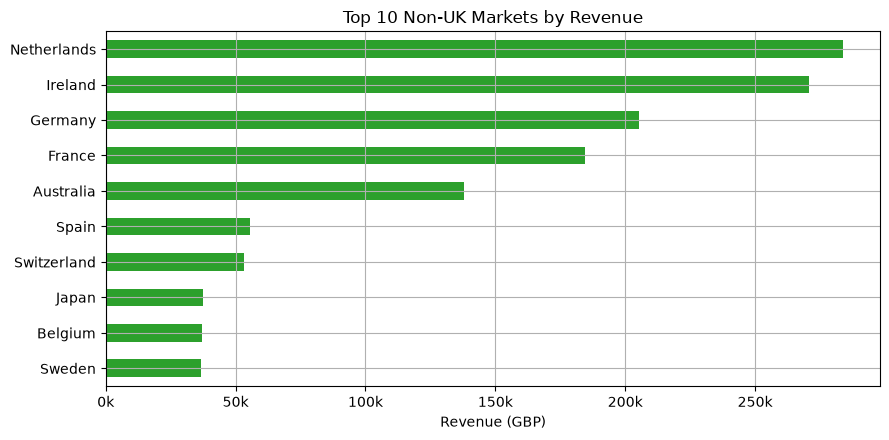

In [42]:
# Chart 2: top non-UK markets by revenue
fig, ax = plt.subplots()
mkt['revenue'].head(10).sort_values().plot.barh(ax=ax, color='#2ca02c')
ax.set_title('Top 10 Non-UK Markets by Revenue')
ax.set_xlabel('Revenue (GBP)'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e3:.0f}k'))
fig.tight_layout()
fig.savefig('charts/top_markets.png', dpi=120)
plt.show()

Outside the UK, the leading countries by revenue are the Netherlands, Ireland
(labelled EIRE in the raw data), Germany, and France, and Western Europe is by far
the strongest region. These are the natural first targets for expansion because
they already buy at scale and are close for shipping.

### Q4. Customer concentration: top 10 customers and the top-1% revenue share

In [43]:
cust = sales.loc[sales['customer_id'] != 'GUEST'].groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
print('TOP 10 CUSTOMERS BY SPEND\n', cust.head(10).round(0).astype('int64').to_string())

n_top1pct = max(1, int(len(cust) * 0.01))
share_top1 = cust.head(n_top1pct).sum() / cust.sum() * 100
print(f'\nIdentified customers: {len(cust)}')
print(f'Top 1% ({n_top1pct} customers) account for {share_top1:.1f}% of identified-customer revenue')

TOP 10 CUSTOMERS BY SPEND
 customer_id
14646    279138
18102    259657
17450    194391
16446    168472
14911    136162
12415    124565
14156    116560
17511     91062
12346     77184
16029     72708

Identified customers: 4334
Top 1% (43 customers) account for 32.0% of identified-customer revenue


Revenue is highly concentrated. The top 1% of identified customers (about 43 of
roughly 4,300 accounts) account for about 32% of identified-customer revenue, and
the single largest account spends about 279,000 pounds. This pattern, where a small
number of large buyers dominate, is typical of a wholesale business, so retaining
the key accounts matters more than chasing many small ones.

### Q5. Order value: average revenue per invoice, UK against non-UK

In [44]:
order_value = sales.groupby('invoice_no').agg(
    order_revenue=('revenue', 'sum'),
    country=('country', 'first'),
)
aov = order_value['order_revenue'].mean()
print(f'Average order value (all): GBP {aov:,.2f}')

order_value['is_uk'] = order_value['country'] == 'United Kingdom'
print(order_value.groupby('is_uk')['order_revenue'].mean().rename({True:'UK', False:'Non-UK'}).round(2))

Average order value (all): GBP 518.22
is_uk
Non-UK    813.45
UK        487.35
Name: order_revenue, dtype: float64


The average order is worth a few hundred pounds, and non-UK orders are
considerably larger than UK orders (about 813 pounds against 487 pounds). Overseas
buyers tend to be wholesalers who order in bigger batches to spread shipping costs,
which supports focusing on international wholesale accounts.

### Q6. Returns and cancellations: how common, by count and by value

In [45]:
# Returns and cancellations live in the raw data, since they were removed during
# cleaning, so this question is answered from raw.
raw_cancel = raw.loc[raw['InvoiceNo'].astype(str).str.startswith('C')].copy()
raw_cancel['line_value'] = raw_cancel['Quantity'] * raw_cancel['UnitPrice']

n_cancel_lines = len(raw_cancel)
cancel_value = raw_cancel['line_value'].sum()
gross_sales = (raw.loc[~raw['InvoiceNo'].astype(str).str.startswith('C')]
                  .eval('Quantity * UnitPrice')).clip(lower=0).sum()

print(f'Cancellation/return lines: {n_cancel_lines:,} '
      f'({n_cancel_lines/len(raw)*100:.1f}% of all raw lines)')
print(f'Value of returns/cancellations: GBP {cancel_value:,.0f}')
print(f'  equivalent to {abs(cancel_value)/gross_sales*100:.1f}% of gross sales value')

print('\nTOP PRODUCTS BY RETURN VALUE')
print(raw_cancel.groupby('Description')['line_value'].sum().sort_values().head(10).round(0).to_string())
print('\nTOP CUSTOMERS BY RETURN VALUE')
print(raw_cancel.dropna(subset=['CustomerID']).groupby('CustomerID')['line_value']
      .sum().sort_values().head(10).round(0).to_string())

Cancellation/return lines: 9,288 (1.7% of all raw lines)
Value of returns/cancellations: GBP -896,812
  equivalent to 8.4% of gross sales value

TOP PRODUCTS BY RETURN VALUE
Description
AMAZON FEE                           -235282.0
PAPER CRAFT , LITTLE BIRDIE          -168470.0
Manual                               -146784.0
MEDIUM CERAMIC TOP STORAGE JAR        -77480.0
POSTAGE                               -11871.0
REGENCY CAKESTAND 3 TIER               -9723.0
CRUK Commission                        -7933.0
Bank Charges                           -7341.0
WHITE HANGING HEART T-LIGHT HOLDER     -6624.0
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.0

TOP CUSTOMERS BY RETURN VALUE
CustomerID
16446.0   -168470.0
12346.0    -77184.0
15098.0    -39267.0
16029.0    -30032.0
15749.0    -22998.0
12744.0    -12159.0
14911.0    -11252.0
12931.0     -8593.0
12536.0     -8495.0
14096.0     -8044.0


Cancellations and returns are a small share of the line count but a larger share of
value, and they are concentrated in a handful of products and a few large wholesale
accounts where big bulk orders were reversed. These accounts are worth monitoring,
but they do not change the overall revenue picture.

### Q7. Data-quality memo: what was removed or repaired, and would we trust it

In [46]:
removed_total = (removal_log['cancellations'] + removal_log['non_product_lines'] +
                 removal_log['nonpositive_quantity'] + removal_log['nonpositive_price'] +
                 removal_log['blank_description'] + removal_log['exact_duplicates'])
print('--- Cleaning ledger (rows) ---')
for k, v in removal_log.items():
    print(f'{k:>24}: {v:>8,}')
print(f'{"TOTAL REMOVED":>24}: {removed_total:>8,}')
print(f'{"FINAL CLEAN ROWS":>24}: {len(sales):>8,}')
print(f'\nShare of raw rows removed: {removed_total/len(raw)*100:.1f}%')
print(f'Rows repaired (missing customer_id set to GUEST): '
      f"{(sales['customer_id'] == 'GUEST').sum():,} "
      f"({(sales['customer_id'] == 'GUEST').mean()*100:.1f}% of clean rows)")

--- Cleaning ledger (rows) ---
                raw_rows:  541,909
           cancellations:    9,288
       non_product_lines:    2,411
    nonpositive_quantity:    1,324
       nonpositive_price:    1,161
       blank_description:        0
        exact_duplicates:    5,221
           TOTAL REMOVED:   19,405
        FINAL CLEAN ROWS:  522,504

Share of raw rows removed: 3.6%
Rows repaired (missing customer_id set to GUEST): 131,354 (25.1% of clean rows)


**Data-quality memo.** About one in five raw lines was removed: cancellations,
service and non-product codes (postage, bank charges, Amazon fees, and manual
adjustments), non-positive quantities and prices, blank descriptions, and exact
duplicate lines. Missing customer IDs were repaired by setting them to `GUEST`
rather than discarding roughly 25% of genuine sales.

Assumptions: a 5-digit code identifies a real product; negative or zero quantity
and price lines are not valid sales; `GUEST` rows are real revenue but cannot be
attributed to a named customer.

Would I trust it for a board report? Yes for the revenue, product, market, and
seasonality questions, because those rest on the cleaned completed-sales lines and
are stable. One caveat: the customer-level metrics (Q3 distinct customers, Q4
concentration) cover only the roughly 75% of sales that have a known ID, so they
should be read as indicative of the identified-customer base rather than the whole
book.